In [1]:
%matplotlib inline
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# PRÁCTICA 2: Clasificación de imágenes con DNNs
## Aprendizaje Profundo para el Análisis de Imágenes
## Grados en Telecomunicación - Universidad Carlos III de Madrid

<center><img src='https://www.uc3m.es/ss/Satellite?blobcol=urldata&blobkey=id&blobtable=MungoBlobs&blobwhere=1371614316787&ssbinary=true' width=400 /></center>


## Introducción

En esta práctica vamos a estudiar cómo crear nuestras primeras Redes Neuronales Profundas (DNNs) y cómo entrenarlas para resolver un problema de clasificación de imágenes.

¿Y cuál es el elemento clave que necesitamos para entrenar una DNN y resolver el problema? DATOS. Necesitamos trabajar con una base de datos real de imágenes, de modo que podamos procesar batches de imágenes de manera iterativa.

En nuestro caso, los datos serán imágenes y sus etiquetas, que indican la categoría de la imagen. El objetivo es leer imágenes y convertirlas en tensores de torch que puedan ser procesados por la red. Para ello, existe un paquete de PyTorch llamado ``torchvision``, que incorpora múltiples funcionalidades para procesar imágenes, como cargadores para datasets habituales como Imagenet, CIFAR10, MNIST, etc. así como transformadores de datos para imágenes.

``torchvision`` utiliza la librería ``Pillow`` para el procesamiento de imágenes.    

La base de datos que vamos a emplear es EuroSAT. Esta base de datos aborda la clasificación del uso y la cobertura del suelo utilizando imágenes de satélite Sentinel-2. Las imágenes del satélite Sentinel-2 son de acceso abierto y gratuito proporcionadas en el programa de observación de la Tierra Copernicus. La base de datos contiene 27000 imágenes en color, de dimensiones 64x64px, correspondientes a 10 posibles categorías del uso de suelo: 'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake'. Por tanto, los tensores torch asociados a las imágenes de entrada a la red serán de tamaño 3x64x64 (3 colores, 64x64 px).

<br/><center><img src='https://raw.githubusercontent.com/phelber/EuroSAT/master/eurosat_overview_small.jpg' width=800/></center>

Cómo entrenar un clasificador de imágenes
----------------------------

Para entrenar un clasificador de imágenes y evaluar su rendimiento, llevaremos a cabo los siguientes pasos:

1. Cargaremos la base de datos y la dividiremos en dos datasets: entrenamiento y test, usando el paquete ``torchvision``
2. Definiremos la arquitectura de una red neuronal profunda (DNN)
3. Definiremos una función de pérdida (loss)
4. Entrenaremos nuestra red utilizando el conjunto de entrenamiento
5. Evaluaremos la red utilizando un conjunto de test


## 1. Cargando y pre-procesando EuroSAT

Es muy sencillo cargar EuroSAT usando ``torchvision``. Puedes acceder a la ayuda de la librería en este [enlace](https://pytorch.org/vision/stable/index.html)

In [4]:
import sys
!{sys.executable} -m pip install torchsummary

In [5]:
pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 5.3 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random
import numpy.random as npr

#Antes de nada, si tenemos GPU la utilizamos
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(device)

cpu


A continuación vamos a definir varios elementos:

- Una cadena de transformaciones a las imágenes que vamos leyendo. Las imágenes de los datasets de ``torchvision`` son imágenes tipo PILImage en el rango [0, 1]. Con la cadena de transformaciones, las convertiremos primero a tensor y luego las normalizaremos. Convertir a tensor implica un cambio en el tipo de datos (a torch.tensor) y una permutación de dimensiones (de HxWxC a CxHxW). La normalización que aplicaremos usará el método de estandarización, restando la media y dividiendo por la desviación típica de cada canal, que previamente hemos calculado. El paquete ``transforms`` de torchvision nos permite implementar éstas y otras transformaciones y el método ``Compose()`` nos permite ejecutarlas secuencialmente.

- Los ``datasets`` de entrenamiento y test. En este caso es muy sencillo pues EuroSAT es una de las bases de datos incluídas en la librería ``torchvision``. Fijaos en que se pasan las transformaciones como argumento del dataset, de modo que cuando accedamos a una imagen, nos devolverán la imagen transformada (convertida a tensor y normalizada). Para más información, [consulte la API de PyTorch](https://docs.pytorch.org/docs/stable/data.html#module-torch.utils.data).

- Los objetos [``DataLoader``](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader), que se encargarán de la lectura de datos y su organización en batches. Este objeto permite correr la lectura de datos en un hilo diferente al entrenamiento y/o ejecución de la DNN y se basa en la capacidad multicore de las máquinas actuales para paralelizar la lectura (usando el parámetro num_workers, que estipula el número de cores que vamos a emplear para leer datos). Con ello se evitan que la lectura de las imágenes se convierta en el cuello de botella del entrenamiento de las DNNs.

In [7]:
# Definimos las transformaciones que le vamos a aplicar a las imágenes:
# En este caso: convertir las imágenes a un tensor, y normalizarlas restando la media
# y dividiendo por la desviación típica de cada canal RGB (los valores se han precalculado)
medias=np.array((0.4278, 0.3821, 0.4112))
desviaciones=np.array((0.0632, 0.0354, 0.0287))
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize(medias,desviaciones)])

#Definimos el tamaño del batch
batchSize=16

#Descargamos la base de datos completa
full_dataset = torchvision.datasets.EuroSAT(root='./data', transform=transform, download=True)
print('La base de datos completa contiene {} imágenes'.format(len(full_dataset)))
print('Las dimensiones de las imágenes son {}'.format(full_dataset[0][0].shape))
#Mostramos las clases de suelo que contiene la base de datos
classes=full_dataset.classes
print('Las clases de la base de datos son {} '.format(classes))

#Dividimos la base de datos en train y test en proporciones 80% y 20%
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
#fijamos la semilla del generador aleatorio para que siempre se divida igual
generator = torch.Generator().manual_seed(42)
trainset, testset = torch.utils.data.random_split(full_dataset, [train_size, test_size],generator=generator)
print('El conjunto de train contiene {} imágenes'.format(len(trainset)))
print('La conjunto de test contiene {} imágenes'.format(len(testset)))
#Definimos la función de carga de datos para el entrenamiento
# - le asignamos el set de entrenamiento
# - definimos batches de batchSize imágenes
# - desordenamos las imágenes (shuffle=true)
# - Usamos 2 cores para paralelizar la carga de datos y agilizar el proceso de lectura
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batchSize,
                                           shuffle=True, num_workers=2)
#Definimos la función de carga de datos para el test
# - le asignamos el set de entrenamiento
# - definimos batches de batchSize imágenes
# - en test no desordenamos
# - Usamos 2 cores para paralelizar la carga de datos y agilizar el proceso de lectura
testloader = torch.utils.data.DataLoader(testset, batch_size=batchSize,
                                         shuffle=False, num_workers=2)



100%|██████████| 94.3M/94.3M [00:10<00:00, 9.03MB/s]


La base de datos completa contiene 27000 imágenes
Las dimensiones de las imágenes son torch.Size([3, 64, 64])
Las clases de la base de datos son ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake'] 
El conjunto de train contiene 21600 imágenes
La conjunto de test contiene 5400 imágenes


<div class="alert alert-info"><h4>NOTA:</h4><p>Si está utilizando Windows y recibe un BrokenPipeError, pruebe a poner el num_worker de torch.utils.data.DataLoader() a 0.</p></div>


**EJERCICIO**

Revise la carpeta ``data`` para ver la base de datos que hemos descargado.

Vamos ahora a visualizar algunas imágenes de la base de datos:


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07450979042053218..1.0000000427246094].


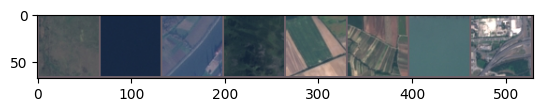

Labels:
1.-HerbaceousVegetation
2.-SeaLake
3.-River
4.-HerbaceousVegetation
5.-AnnualCrop
6.-PermanentCrop
7.-SeaLake
8.-Highway


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pdb

# Definimos una función que nos permite visualizar una imagen
# a partir del tensor torch normalizado
def imshow(img):
    npimg = np.transpose(img.numpy(), (1, 2, 0))
    npimg = npimg * desviaciones + medias     # Desnormalizamos el tensor torch
         # Convertimos el tensor en una matriz numpy
    plt.imshow(npimg) #Reordenamos dimensiones: tensor torch es 3xHxW y pasa a HxWx3
    plt.show() #Lo mostramos

# Cogemos un batch de imágenes aleatorias
dataiter = iter(trainloader) #Generamos un iterador sobre el cargador de imágenes
images, labels = next(dataiter) #Obtenemos las siguientes imágenes

#Nos quedamos únicamente con las 8 primeras para visualizar
numIm=np.minimum(images.shape[0],8)

# Las mostramos (make_grid las concatena en un grid espacial para mostrarlas todas juntas)
imshow(torchvision.utils.make_grid(images[:numIm,...]))
# Mostramos las etiquetas
print('Labels:\n' + '\n'.join('%d.-%s' % (j+1,classes[labels[j]]) for j in range(numIm)))

## 2. Definición de una Red Neuronal Profunda Completamente Conectada (FCDNN)

Creamos la red:

In [10]:
class FCDNNet(nn.Module):
# FCDNNet is now a subclass of nn.Module
  def __init__(self):
  # This is the constructor method for the ClassANN class.
  # The __init__ method is a special method in Python classes that is
  # automatically called when an instance of the class is created.
  # It is used to initialize the object's attributes.
    super().__init__()
    # This line calls the constructor of the parent class (nn.Module) using
    # the super() function.

    # Flatten layer
    self.flatten = nn.Flatten()

    # Input layer
    self.input = nn.Linear(64*64*3,8)

    # Hidden Layers
    self.hidden1 = nn.Linear(8,4)
    #self.hidden2 = nn.Linear(4,4)

    # Output Layer
    self.output = nn.Linear(4,10)

  def forward(self, x):
    x = self.flatten(x)
    x = F.relu(self.input(x))
    x = F.relu(self.hidden1(x))
    #x = F.relu(self.hidden2(x))
    x = self.output(x)
    return x


Solamente tenemos que definir la función ``forward()``, ya que la función ``backward()`` (donde se calculan los gradientes) se define automáticamente usando el módulo autograd. Podemos usar cualquier operación permitida a un tensor dentro de la función forward, así como invocar a módulos de nn.Module o nn.Functional.

Las capas que requieran información de estado (todas las que tengan parámetros, atributos o pesos) se pueden definir en el inicio (método __init__()) para que queden parametrizadas. Aquellas capas que simplemente ejecuten una ecuación sin parámetros (por ej. Relu) no tienen que definirse al inicio y pueden simplemente llamarse como funciones en torch.nn.functional (ver por ej. F.relu)

IMPORTANTE: En ``__init__()`` definimos capas que serán necesarias, pero no la estructura de la red. La estructura de la red se define por código en el método forward(). Para que entendamos este punto, es importante entender que el método ``__init__()`` puede incluir una capa de procesado (por ej. una capa convolucional) pero, si luego esa capa no se ejecuta en el método ``forward()``, es como si no la hubiésemos definido y no forma parte de la red.

**IMPORTANTE SI QUIERE CAMBIAR LA ARQUITECTURA DE LA RED**: la estructura de la red debe de ser acorde para lograr transformar el tensor de entrada de cada imagen Nx3x64x64 (N el número de imágenes en el batch,3 los canales RGB, y 64 las dimensiones espaciales) en el tensor con los scores de cada caso de tamaño Nx10 (N el número de imágenes del batch y 10 las 10 clases del problema). Para ello, tiene que ajustar la arquitectura, incluyendo el número de capas, los strides de cada una, etc. de modo que consiga transformar el tensor en el vector final. Como ayuda, se proporciona el siguiente código que le permite ejecutar la red sobre un batch de imágenes y ver cuál es la forma de la salida generada.

In [12]:
#First check of the model
net = FCDNNet().to(device)

#Obtenemos un batch de datos y extraemos imágenes y etiquetas
data=next(iter(trainloader))
inputs = data[0].to(device).float()
labels = data[1].to(device)

print('El tamaño del tensor que representa un batch de imágenes es {}'.format(inputs.shape))

#Lo pasamos por la red
with torch.set_grad_enabled(False):
    outputs = net(inputs)
    print('El tamaño del tensor de salida es {}'.format(outputs.shape))

El tamaño del tensor que representa un batch de imágenes es torch.Size([16, 3, 64, 64])
El tamaño del tensor de salida es torch.Size([16, 10])


In [15]:
# First check of the model
net = FCDNNet().to(device)

# Summary
summary(net, (1,64*64*3))

# Using random data
random_data = torch.randn((4,64*64*3)).to(device)
print(random_data.shape)
yp = net(random_data)
print(yp.shape)

# Using real data
data = next(iter(trainloader))
inputs = data[0].to(device)
labels = data[1]
print("\n")
print(inputs.shape)
print(labels.shape)
print(labels)

yp2 = net(inputs)
print("\n")
print(yp2.shape)
# print("\n")
# print(yp2[:2,:].detach())
# print(torch.argmax(yp2[:2,:],axis=1))
# print(labels[:2])
# correct_bool = ( torch.argmax(yp2,axis=1) == labels )
# print(correct_bool.float())

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                [-1, 12288]               0
            Linear-2                    [-1, 8]          98,312
            Linear-3                    [-1, 4]              36
            Linear-4                   [-1, 10]              50
Total params: 98,398
Trainable params: 98,398
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.05
Forward/backward pass size (MB): 0.09
Params size (MB): 0.38
Estimated Total Size (MB): 0.52
----------------------------------------------------------------
torch.Size([4, 12288])
torch.Size([4, 10])




torch.Size([16, 3, 64, 64])
torch.Size([16])
tensor([3, 1, 5, 6, 1, 1, 1, 3, 9, 9, 7, 1, 7, 9, 9, 5])


torch.Size([16, 10])


### 2.1 Función de pérdida y optimizador

#### Función de pérdida
Una función de pérdida coge el par (salida, etiquetas), y calcula un valor que estima cómo de parecida es la salida a la etiqueta.

Hay varias funciones de pérdida ya implementadas en PyTorch en el paquete nn ([ver enlace](https://pytorch.org/docs/stable/nn.html#loss-functions)). En nuestro caso vamos a utilizar como función de pérdida una entropía cruzada multiclase (nn.CrossEntropyLoss), que integra un nn.LogSoftmax() y un nn.NLLLoss().

#### Optimizador
Para encontrar los valores de los pesos que optimicen el rendimiento de la red utilizaremos la estrategia de mini-batch SGD. El código del SGD no es necesario pues PyTorch cuenta con optimizadores que realizan la actualización de los pesos. Encontramos optimizadores como SGD, Nesterov-SGD, Adam, RMSPro, etc.

Para utilizarlos, emplearemos el módulo ``torch.optim``. En este caso, usaremos un optimizador de SGD con momento (ver diapositivas), utilizando un learning rate de 1e-3 y un momento de 0.9.


In [16]:
pip install torch.optim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 3.6 MB/s  0:00:16m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [torch.optim] [torch.optim]te]
Note: you may need to restart the kernel to use updated packages.


In [17]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

### 2.2 Entrenamiento de la DNN

Por fin vamos a entrenar una red neuronal profunda sobre datos reales.
El proceso es simple, tenemos que hacer un bucle donde demos los diferentes pasos:
- Lectura de datos
- Paso forward (cálculo de las salidas de la red)
- Evaluación de la función de pérdida
- Paso backward (cálculo de gradientes)
- Actualización de los pesos

In [18]:
import time

def trainNetwork(net,trainset,trainloader,criterion,optimizer,num_epochs=5):

    #We fix seeds for reproducibility
    random.seed(42)
    npr.seed(42)
    torch.manual_seed(42)
    torch.backends.cudnn.benchmark = True

    #Precalculamos el número de iteraciones
    numTrainImages=len(trainset)
    numIters=np.ceil(numTrainImages/batchSize)
    tict = time.perf_counter()
    for epoch in range(num_epochs):  # Hacemos dos iteraciones completas (epochs) sobre la base de datos
        #Al principio de cada epoch, reinicializamos la pérdida total
        running_loss = 0.0
        #Iteramos sobre el cargador de datos, dividiendo la base de datos en batches de 4 imágenes
        #Comenzamos en la iteración i=0 (argumento opcional de enumerate)
        tic = time.perf_counter()
        for i, data in enumerate(trainloader, 0):
            # data es una dupla, la dividimos los datos en entradas y etiquetas (y convertimos al device correspondiente)
            inputs = data[0].to(device)
            labels = data[1].to(device)

            # Ponemos a cero los gradientes
            optimizer.zero_grad()

            # forward
            outputs = net(inputs)

            # evaluamos la función de pérdida
            loss = criterion(outputs, labels)

            # backward
            loss.backward()

            #actualizamos los pesos con el optimizador
            optimizer.step()

            # Acumulamos las loss
            running_loss += loss.item()

        # Mostramos info detallada al final de cada epoch
        #Contamos el tiempo pasado
        toc = time.perf_counter()
        time_s=(toc-tic)
        print('[epoch %d] loss: %.3f epoch_time: %.3f s' %
                  (epoch + 1, running_loss/numIters , time_s))
        #Reseteamos la running loss
        running_loss = 0.0
        #Reseteamos el reloj
        tic = time.perf_counter()

    toct = time.perf_counter()
    tot_time=toct-tict
    print('Entrenamiento finalizado en %.2f segs'%tot_time)
    return net

In [19]:
net=trainNetwork(net,trainset,trainloader,criterion,optimizer,num_epochs=10)

[epoch 1] loss: 2.031 epoch_time: 17.808 s
[epoch 2] loss: 1.775 epoch_time: 17.719 s
[epoch 3] loss: 1.618 epoch_time: 17.354 s
[epoch 4] loss: 1.565 epoch_time: 17.892 s
[epoch 5] loss: 1.530 epoch_time: 19.031 s
[epoch 6] loss: 1.487 epoch_time: 17.728 s
[epoch 7] loss: 1.462 epoch_time: 18.104 s
[epoch 8] loss: 1.413 epoch_time: 17.968 s
[epoch 9] loss: 1.392 epoch_time: 17.877 s
[epoch 10] loss: 1.366 epoch_time: 17.747 s
Entrenamiento finalizado en 179.24 segs


### 2.3 Evaluación de la DNN utilizando un conjunto de test

Hemos entrenado la DNN durante 10 épocas sobre el conjunto de entenamiento. Ahora vamos a comprobar si la red ha aprendido algo.

Lo haremos comprobando si la etiqueta predicha por la red conincide con la etiqueta verdadera (ground truth) y evaluándo la proporción de etiquetas correctas (accuracy).

Para empezar vamos a mostrar algunas imágenes de test con sus etiquetas:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.12156861953735348..1.0000000427246094].


torch.Size([16, 3, 64, 64])


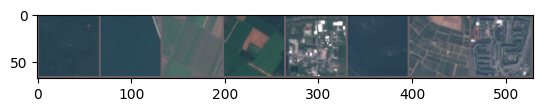

Labels:
1.-Forest
2.-SeaLake
3.-AnnualCrop
4.-AnnualCrop
5.-Industrial
6.-Forest
7.-PermanentCrop
8.-Residential


In [20]:
#Iteramos el test
dataiter = iter(testloader)
images, labels = next(dataiter)


#El tensor images tiene dimensiones NxCxHxW (N imágenes en el batch, C canales, H,W dimensiones espaciales)
print(images.size())

#Nos quedamos únicamente con las 8 primeras para visualizar
numIm=np.minimum(images.shape[0],8)

# Las mostramos (make_grid las concatena en un grid espacial para mostrarlas todas juntas)
imshow(torchvision.utils.make_grid(images[:numIm,...]))
# Mostramos las etiquetas
print('Labels:\n' + '\n'.join('%d.-%s' % (j+1,classes[labels[j]]) for j in range(numIm)))

Ahora vamos a comprobar las salidas de la red para las imágenes de test:


In [21]:
outputs = net(images.to(device))

Las salidas de la red son los scores de las 10 clases consideradas en la base de datos EuroSAT. Cuanto mayor es la energía, mayor es la probabilidad de que la imagen muestre es clase. También podemos calcular las probabilidades mediante un softmax, para dar una idea de cómo de segura está la red de sus decisiones. Además, para saber la clase asignada, simplemente buscamos el valor máximo en las probs:


In [22]:
#Aplicamos un softmax a las salidas
out_probs=F.softmax(outputs.data,dim=1)
max_prob, predicted = torch.max(out_probs, 1)

print('Predicted: ', ' '.join('%5s %.3f%%' % (classes[predicted[j]],max_prob[j])
                              for j in range(batchSize)))

Predicted:  Forest 0.609% River 0.442% Highway 0.224% HerbaceousVegetation 0.691% Industrial 0.755% SeaLake 0.610% Highway 0.350% Residential 0.442% AnnualCrop 0.316% Residential 0.359% Forest 0.789% AnnualCrop 0.733% Residential 0.366% SeaLake 0.855% PermanentCrop 0.276% HerbaceousVegetation 0.239%


Los resultados son aceptables data la red tan sencilla que estamos usando y para haber entrenado únicamente diez épocas.

Vamos ahora a evaluar la red sobre todo el conjunto de test.


In [23]:
correct = 0
total = 0
with torch.no_grad(): #Ponemos esta línea de código para evitar que torch registre las operaciones y calcule grads.
    for data in testloader:
        images = data[0].to(device)
        labels = data[1].to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('La tasa de acierto (accuracy) del modelo sobre un conjunto de test es: %.2f %%' % (
    100 * correct / total))

La tasa de acierto (accuracy) del modelo sobre un conjunto de test es: 44.70 %


Estos resultados, a pesar de la sencillez de la red y del poco entrenamiento, parecen muy superiores a la tasa de acierto de un sistema que eligiese una clase de forma aleatoria, que sería de un 10% (tenemos 10 clases).

Esto nos dice que la red ha aprendido algo. De todos modos, podemos sacar más conclusiones si estudiamos los resultados a nivel de categoría a través de la matriz de confusión:



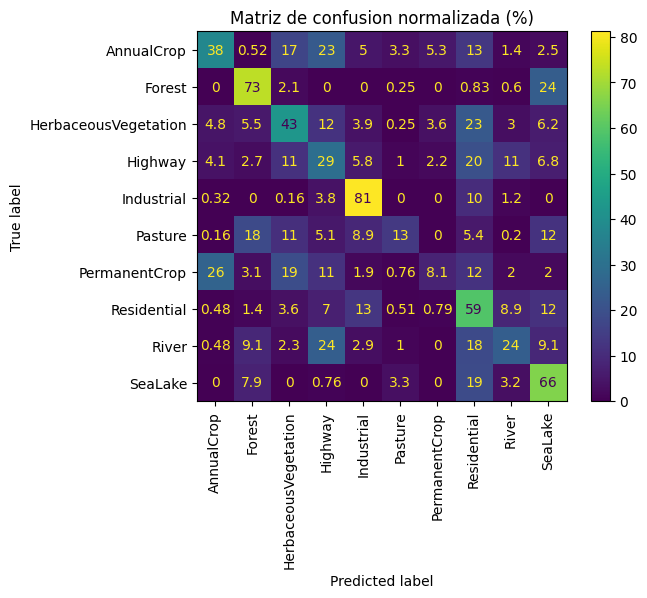

In [24]:
import sklearn.metrics as skm
import matplotlib.pyplot as plt


numTestImages=len(testset)

#Vamos a contabilizar de forma independiente las diferentes clases
class_pred = np.zeros((numTestImages,),dtype=int)
class_gt = np.zeros((numTestImages,),dtype=int)

#No calculamos grads
iteration=0
with torch.no_grad():

    for data in testloader:
        images = data[0].to(device)
        labels = data[1].to(device)
        outputs = net(images.to(device))
        _, predicted = torch.max(outputs, 1)
        class_pred[iteration*batchSize:(iteration+1)*batchSize]=predicted.cpu().numpy()
        class_gt[iteration*batchSize:(iteration+1)*batchSize]=labels.cpu().numpy()
        iteration+=1

cm=skm.confusion_matrix(class_gt, class_pred)
#print(cm)
#La normalizamos para que cada fila sume 1 y así tenemos probs
ncm=cm/cm.sum(axis=1)
#Vamos a mostrar en porcentajes en vez de probs
ncmd=skm.ConfusionMatrixDisplay(100*ncm,display_labels=classes)
ncmd.plot(xticks_rotation='vertical')
plt.title('Matriz de confusion normalizada (%)')
plt.show()


## Experimentos adicionales

### A) Evalúe los resultados de la matriz de confusión y saque conclusiones acerca de:
- ¿Por qué algunas categorías pueden funcionar mejor que otras?
- ¿Entre qué categorías se dan más casos de confusión? ¿Tiene sentido que así sea?

#### Conclusiones del análisis de la matriz de confusión

El rendimiento de la red FCDNN varía drásticamente entre categorías, y esto se explica por la distintividad visual de cada clase. Las categorías con mejor tasa de acierto son **Industrial (81%)**, **Forest (73%)** y **SeaLake (66%)**, ya que poseen patrones visuales muy característicos y diferenciados del resto: las zonas industriales presentan formas geométricas y tejados regulares, los bosques muestran una textura verde oscura homogénea, y los lagos/mares destacan por grandes superficies azules uniformes. Estas diferencias en color y textura son lo suficientemente marcadas como para que incluso una red sin capas convolucionales, que solo trabaja con los valores individuales de los píxeles aplanados en un vector, logre discriminarlas razonablemente. En cambio, categorías como **PermanentCrop (8.1%)**, **Pasture (13%)** o **HerbaceousVegetation (12%)** obtienen resultados muy pobres porque su apariencia visual es extremadamente similar entre sí —todas son superficies de vegetación con tonalidades verdes y marrones— y la red carece de la capacidad de extraer patrones espaciales locales que permitan distinguir matices sutiles de textura.

Las confusiones más frecuentes se dan entre categorías que comparten similitudes visuales evidentes. Por un lado, las clases de vegetación se confunden sistemáticamente entre sí: **PermanentCrop se clasifica como AnnualCrop en un 26% de los casos**, ya que ambas representan terrenos de cultivo con apariencia prácticamente idéntica en imágenes satelitales de 64×64 píxeles. De forma similar, **HerbaceousVegetation se confunde con Residential (23%)** y **Pasture con Forest (18%)**. Por otro lado, existe una confusión muy significativa entre **Highway y River**: las carreteras se predicen como River en un 11% de los casos, y los ríos se clasifican como Highway en un 24%, lo cual se debe a que ambas clases comparten una geometría lineal elongada y tonalidades oscuras similares cuando se observan desde el satélite. También destaca la confusión de **Residential** absorbiendo predicciones de múltiples categorías (Highway 20%, HerbaceousVegetation 23%), dado que las zonas residenciales son paisajes heterogéneos que contienen elementos de otras clases como carreteras, vegetación y edificios.

Todas estas confusiones tienen pleno sentido desde un punto de vista visual y estructural. La red FCDNN aplana cada imagen en un vector de 12.288 valores (64×64×3) perdiendo completamente la información de relaciones espaciales entre píxeles vecinos, lo que la incapacita para captar diferencias de textura, forma o estructura geométrica que serían clave para discriminar entre clases similares. En esencia, la red solo puede apoyarse en estadísticas globales de color para clasificar, y cuando dos categorías comparten paletas de colores parecidas —como ocurre entre los distintos tipos de vegetación o entre ríos y carreteras— el modelo colapsa y las confunde de forma sistemática. Esto pone de manifiesto las limitaciones inherentes de una arquitectura completamente conectada para tareas de clasificación de imágenes, y justifica la necesidad de avanzar hacia redes convolucionales (CNNs) que sí preserven y exploten la estructura espacial de las imágenes.

### B) Modifique la arquitectura de la red
- Puede probar a poner más o menos neuronas en las capas.
- Puede probar a poner o quitar alguna capa completamente conectada (fully connected o Linear) más o menos. Revise que la arquitectura es congruente con la celda de código proporcionada para tales efectos.


In [30]:
##Creacion de class para el modelo con más neuronas por capa( Debería mejorar notable respecto al baseline. La red tiene mucha más capacidad para representar patrones complejos en los datos.)
class FCDNNet_v1(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.input = nn.Linear(64*64*3, 128)
        self.hidden1 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.input(x))
        x = F.relu(self.hidden1(x))
        x = self.output(x)
        return x
## Creaciin de class para el modelo con menos neuronas por capa ( Debería empeorar respecto al baseline. La red tiene menos capacidad para representar patrones complejos en los datos.)
class FCDNNet_v2(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.input = nn.Linear(64*64*3, 4)
        self.output = nn.Linear(4, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.input(x))
        x = self.output(x)
        return x
## Creación de class para el modelo con mayor profundidad (Más profundidad permite a la red aprender representaciones jerárquicas más complejas)
class FCDNNet_v3(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.input = nn.Linear(64*64*3, 128)
        self.hidden1 = nn.Linear(128, 64)
        self.hidden2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.input(x))
        x = F.relu(self.hidden1(x))
        x = F.relu(self.hidden2(x))
        x = self.output(x)
        return x
## Creación de class para el model con mayor profundidad y más neruronas por capa(Probablemente el mejor resultado de todas las variaciones FC. El Dropout ayuda a regularizar y evitar sobreajuste)
class FCDNNet_v4(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.input = nn.Linear(64*64*3, 256)
        self.hidden1 = nn.Linear(256, 128)
        self.hidden2 = nn.Linear(128, 64)
        self.hidden3 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 10)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.input(x))
        x = self.dropout(x)
        x = F.relu(self.hidden1(x))
        x = self.dropout(x)
        x = F.relu(self.hidden2(x))
        x = F.relu(self.hidden3(x))
        x = self.output(x)
        return x

In [31]:
# =====================================================================
# 2) DICCIONARIO DE MODELOS A ENTRENAR
# =====================================================================

models_config = {
    "Original\n(8→4)":        FCDNNet,
    "V1 Ancho\n(128→64)":     FCDNNet_v1,
    "V2 Estrecho\n(4)":       FCDNNet_v2,
    "V3 Profundo\n(128→64→32)": FCDNNet_v3,
    "V4 Max+Drop\n(256→128→64→32)": FCDNNet_v4,
}

NUM_EPOCHS = 10


In [32]:
# =====================================================================
# 3) ENTRENAMIENTO Y EVALUACIÓN DE TODOS LOS MODELOS
# =====================================================================

results = {}  # Almacena: accuracy, tiempo, confusion matrix normalizada

for model_name, ModelClass in models_config.items():
    print(f"\n{'='*60}")
    print(f" Entrenando: {model_name.replace(chr(10), ' ')}")
    print(f"{'='*60}")

    # Fijar semillas para reproducibilidad
    random.seed(42)
    npr.seed(42)
    torch.manual_seed(42)
    torch.backends.cudnn.benchmark = True

    # Crear red, loss y optimizador
    net = ModelClass().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

    # Contar parámetros
    num_params = sum(p.numel() for p in net.parameters() if p.requires_grad)

    # Entrenar midiendo tiempo total
    tic = time.perf_counter()
    net = trainNetwork(net, trainset, trainloader, criterion, optimizer, num_epochs=NUM_EPOCHS)
    train_time = time.perf_counter() - tic

    # Evaluar en test
    numTestImages = len(testset)
    class_pred = np.zeros((numTestImages,), dtype=int)
    class_gt = np.zeros((numTestImages,), dtype=int)

    correct = 0
    total = 0
    iteration = 0
    net.eval()
    with torch.no_grad():
        for data in testloader:
            images = data[0].to(device)
            labels = data[1].to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            bs = labels.size(0)
            class_pred[iteration*batchSize:iteration*batchSize+bs] = predicted.cpu().numpy()
            class_gt[iteration*batchSize:iteration*batchSize+bs] = labels.cpu().numpy()
            iteration += 1

    accuracy = 100 * correct / total

    # Matriz de confusión normalizada (%)
    cm = skm.confusion_matrix(class_gt, class_pred)
    ncm = 100 * cm / cm.sum(axis=1, keepdims=True)

    results[model_name] = {
        'accuracy': accuracy,
        'time': train_time,
        'ncm': ncm,
        'params': num_params,
    }

    print(f" → Accuracy: {accuracy:.2f}% | Tiempo: {train_time:.1f}s | Params: {num_params:,}")




 Entrenando: Original (8→4)
[epoch 1] loss: 2.100 epoch_time: 19.338 s
[epoch 2] loss: 1.887 epoch_time: 18.848 s
[epoch 3] loss: 1.769 epoch_time: 19.515 s
[epoch 4] loss: 1.734 epoch_time: 17.973 s
[epoch 5] loss: 1.647 epoch_time: 18.180 s
[epoch 6] loss: 1.603 epoch_time: 19.686 s
[epoch 7] loss: 1.566 epoch_time: 17.801 s
[epoch 8] loss: 1.552 epoch_time: 17.679 s
[epoch 9] loss: 1.523 epoch_time: 17.878 s
[epoch 10] loss: 1.497 epoch_time: 18.237 s
Entrenamiento finalizado en 185.15 segs
 → Accuracy: 42.50% | Tiempo: 185.2s | Params: 98,398

 Entrenando: V1 Ancho (128→64)
[epoch 1] loss: 1.474 epoch_time: 17.778 s
[epoch 2] loss: 1.238 epoch_time: 18.003 s
[epoch 3] loss: 1.127 epoch_time: 17.907 s
[epoch 4] loss: 1.059 epoch_time: 17.896 s
[epoch 5] loss: 0.991 epoch_time: 17.784 s
[epoch 6] loss: 0.925 epoch_time: 20.896 s
[epoch 7] loss: 0.868 epoch_time: 18.205 s
[epoch 8] loss: 0.819 epoch_time: 18.738 s
[epoch 9] loss: 0.780 epoch_time: 18.508 s
[epoch 10] loss: 0.746 epoc

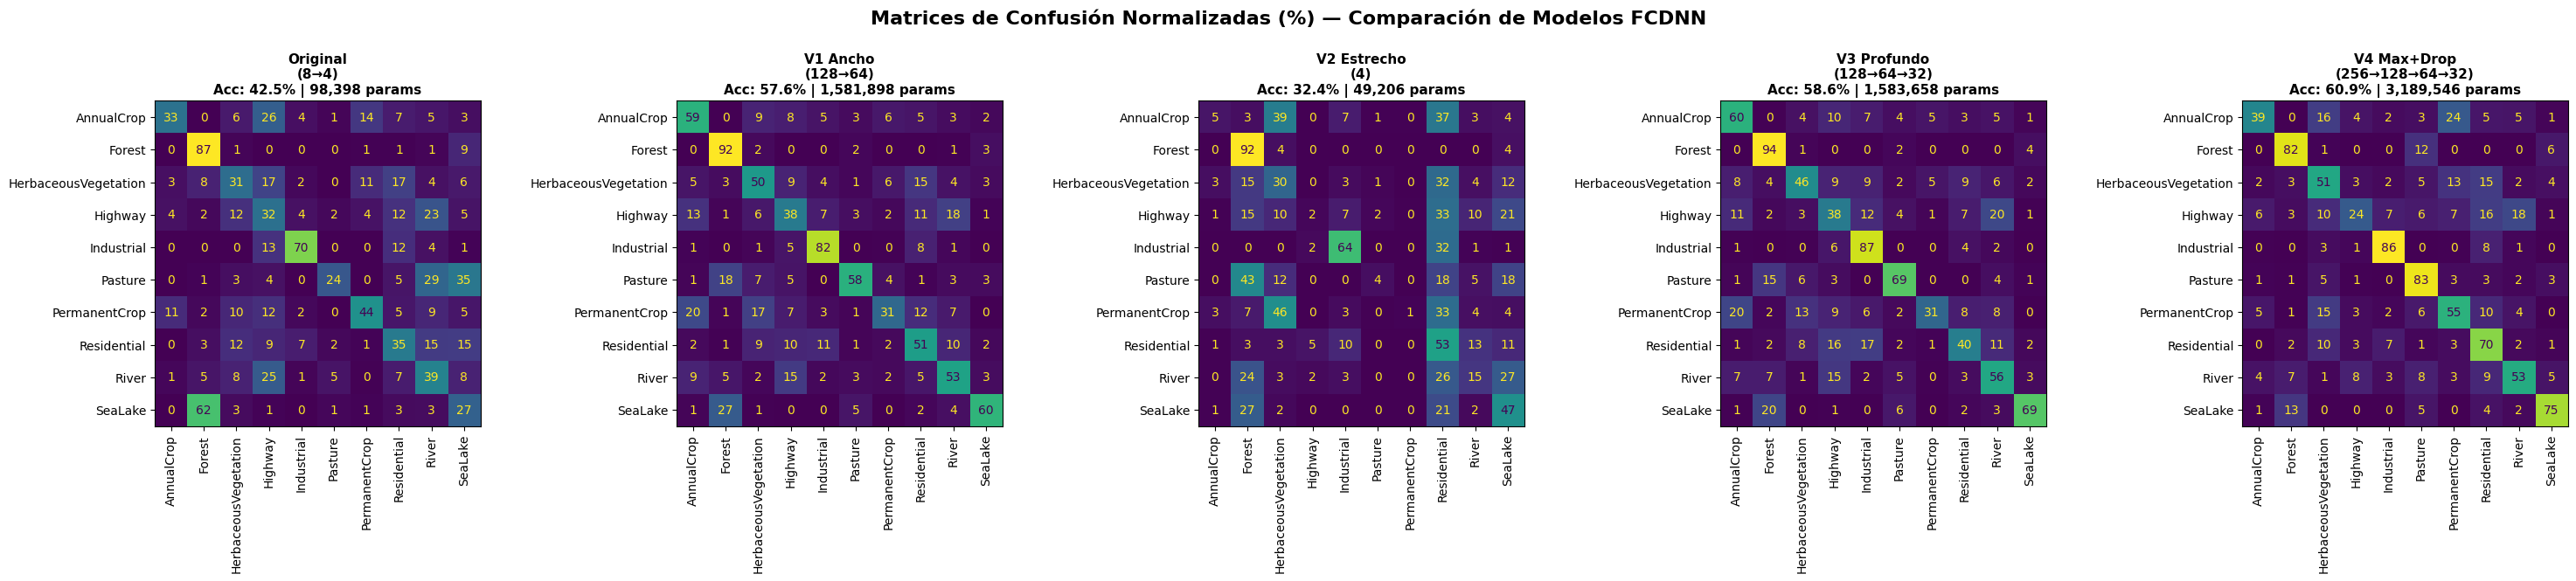

In [33]:
# =====================================================================
# 4) GRÁFICA 1: MATRICES DE CONFUSIÓN (subplots)
# =====================================================================

n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 6))
fig.suptitle('Matrices de Confusión Normalizadas (%) — Comparación de Modelos FCDNN',
             fontsize=16, fontweight='bold', y=1.05)

for idx, (model_name, res) in enumerate(results.items()):
    ax = axes[idx]
    disp = skm.ConfusionMatrixDisplay(res['ncm'], display_labels=classes)
    disp.plot(ax=ax, xticks_rotation='vertical', values_format='.0f', colorbar=False)
    ax.set_title(f"{model_name}\nAcc: {res['accuracy']:.1f}% | {res['params']:,} params",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('comparacion_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

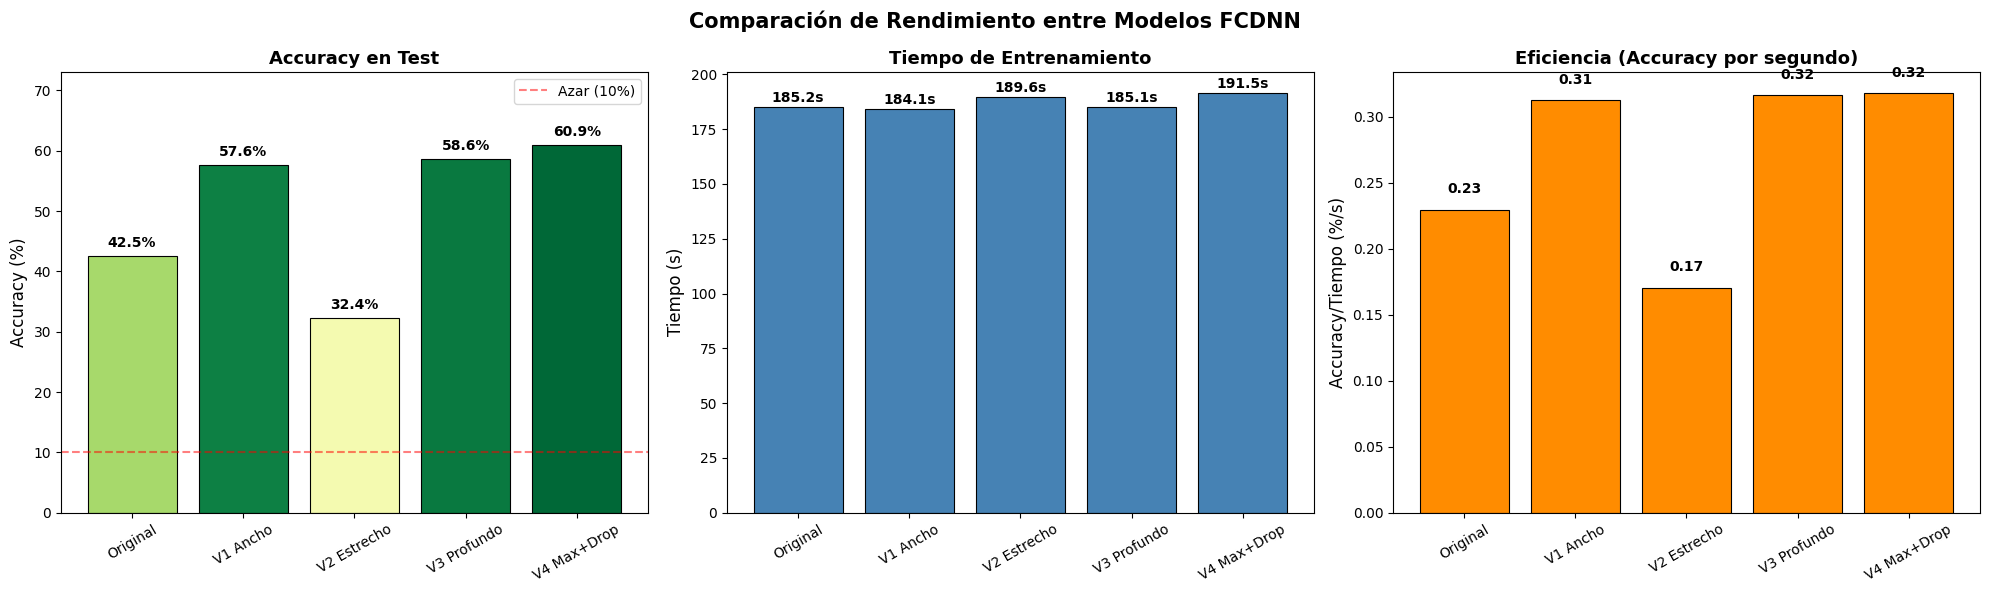

In [34]:
# =====================================================================
# 5) GRÁFICA 2: COMPARACIÓN DE ACCURACY Y TIEMPO DE ENTRENAMIENTO
# =====================================================================

model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
times = [results[m]['time'] for m in model_names]
params = [results[m]['params'] for m in model_names]

# Nombres cortos para el eje X
short_names = [n.split('\n')[0] for n in model_names]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Comparación de Rendimiento entre Modelos FCDNN',
             fontsize=15, fontweight='bold')

# --- Subplot 1: Accuracy ---
colors = plt.cm.RdYlGn(np.array(accuracies) / max(accuracies))
bars1 = ax1.bar(short_names, accuracies, color=colors, edgecolor='black', linewidth=0.8)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Accuracy en Test', fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(accuracies) * 1.2)
ax1.axhline(y=10, color='red', linestyle='--', alpha=0.5, label='Azar (10%)')
ax1.legend()
for bar, acc in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax1.tick_params(axis='x', rotation=30)

# --- Subplot 2: Tiempo de entrenamiento ---
bars2 = ax2.bar(short_names, times, color='steelblue', edgecolor='black', linewidth=0.8)
ax2.set_ylabel('Tiempo (s)', fontsize=12)
ax2.set_title('Tiempo de Entrenamiento', fontsize=13, fontweight='bold')
for bar, t in zip(bars2, times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{t:.1f}s', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax2.tick_params(axis='x', rotation=30)

# --- Subplot 3: Eficiencia (Accuracy / Tiempo) ---
efficiency = [a / t for a, t in zip(accuracies, times)]
bars3 = ax3.bar(short_names, efficiency, color='darkorange', edgecolor='black', linewidth=0.8)
ax3.set_ylabel('Accuracy/Tiempo (%/s)', fontsize=12)
ax3.set_title('Eficiencia (Accuracy por segundo)', fontsize=13, fontweight='bold')
for bar, e in zip(bars3, efficiency):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{e:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax3.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('comparacion_rendimiento.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
print("\n" + "="*80)
print(f"{'MODELO':<30} {'ACCURACY':>10} {'TIEMPO':>10} {'PARÁMETROS':>15} {'EFICIENCIA':>12}")
print("="*80)
for model_name in model_names:
    r = results[model_name]
    short = model_name.split('\n')[0]
    eff = r['accuracy'] / r['time']
    print(f"{short:<30} {r['accuracy']:>9.2f}% {r['time']:>9.1f}s {r['params']:>14,} {eff:>11.2f}%/s")
print("="*80)


MODELO                           ACCURACY     TIEMPO      PARÁMETROS   EFICIENCIA
Original                           42.50%     185.2s         98,398        0.23%/s
V1 Ancho                           57.59%     184.1s      1,581,898        0.31%/s
V2 Estrecho                        32.35%     189.6s         49,206        0.17%/s
V3 Profundo                        58.59%     185.1s      1,583,658        0.32%/s
V4 Max+Drop                        60.91%     191.5s      3,189,546        0.32%/s



### C) Modifique los parámetros de entrenamiento
- Pruebe otros valores del learning rate y explique si el entrenamiento converge y si los resultados mejoran o empeoran.
- Pruebe otros valores del weight decay y explique qué sucede con el rendimiento de la red.


## 3. Definición de una Red Neuronal Convolucional (CNN)

Ahora vamos a usar una red CNN muy parecida a LeNet [LeCun et al., 1998], que inicialmente fue concebida para la clasificación de dígitos. La red original LeNet se muestra a continuación:

![Image of LeNet](https://pytorch.org/tutorials/_images/mnist.png)

LeNet es una red neuronal convolucional (CNN) hacia delante (feed-forward), lo que implica que no tiene ningún lazo de realimentación. Estas son las redes más sencillas. La red recibe una entrada, calcula las diferentes etapas de procesado siempre hacia delante (la salida de una etapa es la entrada a la siguiente), una tras otra, y proporciona la salida correspondiente.

Para crear redes neuronales debemos usar el paquete ``torch.nn``. ``nn`` utiliza autograd para definir modelos o redes y poder derivarlos para aplicar optimización por descenso por gradiente.

La clase nn.Module implementa un módulo de procesado y permite empaquetar diferentes capas o niveles de la red, y dispone de un método .forward(input) que retorna la salida de la red.

Revise el siguiente código y lea la siguiente celda, pues contiene explicaciones. Como podrá comprobar, la red está inspirada en LeNet, pero es algo más compleja.


In [25]:
class CNNet(nn.Module):
    def __init__(self):
        # En el inicializador vamos a especificar los bloques de cómputo que tienen parámetros a definir
        # OJO: los definimos de forma independiente => De momento son bloques aislados y no forman una red
        super(CNNet, self).__init__()
        # Capa convolucional:
        # canales in = 3 (la imagen de entrada tiene 3 canales RGB)
        # 8 canales out
        # filtro de tamaño 5x5
        self.conv1 = nn.Conv2d(3, 8, 5,padding=2)
        # Capa de Maxpooling con tamaño 2x2
        self.pool = nn.MaxPool2d(2, 2)
        # Capa convolucional:
        # canales in = 8 (de la capa anterior)
        # 16 canales out
        # filtro de tamaño 5x5
        self.conv2 = nn.Conv2d(8, 16, 5,padding=2)
        # Capa de Maxpooling con tamaño 2x2
        # Capa convolucional:
        # canales in = 16 (de la capa anterior)
        # 64 canales out
        # filtro de tamaño 5x5
        self.conv3 = nn.Conv2d(16, 32, 5,padding=2)
        # Capa completamente conectada (y = Wx + b)
        # canales in = 32 * 8 * 8 (32 capa anterior, 8x8 es la dimensión de la imagen que llega a esta capa)
        # canales out = 128
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        # Capa completamente conectada (y = Wx + b)
        # canales in = 128 (capa anterior)
        # canales out = 256
        self.fc2 = nn.Linear(128, 256)
        # Capa completamente conectada (y = Wx + b)
        # canales in = 256 (capa anterior)
        # canales out = 10 (tenemos 10 dígitos a clasificar)
        self.fc3 = nn.Linear(256, 10)
    #En forward definimos la red a través de su grafo computacional
    #Es donde conectamos los bloques antes definidos y metemos otros más simples
    def forward(self, x):

        # Entrada -> conv1 -> activación relu -> Max pooling sobre una ventana (2, 2) -> x
        x = self.pool(F.relu(self.conv1(x)))
        # x -> conv2 -> activación relu -> Max pooling sobre una ventana (2, 2)
        x = self.pool(F.relu(self.conv2(x)))
        # x -> conv2 -> activación relu -> Max pooling sobre una ventana (2, 2)
        x = self.pool(F.relu(self.conv3(x)))
        # Vectorizamos usando la función flatten, pero lo hacemos desde la dim=1 para no romper el batch
        x = x.flatten(start_dim=1)
        # x -> fc1 -> relu
        x = F.relu(self.fc1(x))
        # x -> fc2 -> relu
        x = F.relu(self.fc2(x))
        # x -> fc3
        x = self.fc3(x)
        return x

Creamos la red:

In [26]:
#We fix seeds for reproducibility
random.seed(42)
npr.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.benchmark = True

net = CNNet() #Invocamos el constructor de la red (método init())
net.to(device) #Pasamos la red al device que estemos usando (gpu)

CNNet(
  (conv1): Conv2d(3, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv3): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)

In [27]:
#Obtenemos un batch de datos y extraemos imágenes y etiquetas
data=next(iter(trainloader))
inputs = data[0].to(device).float()
labels = data[1].to(device)

print('El tamaño del tensor que representa un batch de imágenes es {}'.format(inputs.shape))

#Lo pasamos por la red
with torch.set_grad_enabled(False):
    outputs = net(inputs)
    print('El tamaño del tensor de salida es {}'.format(outputs.shape))

El tamaño del tensor que representa un batch de imágenes es torch.Size([16, 3, 64, 64])
El tamaño del tensor de salida es torch.Size([16, 10])


### 3.1 Función de pérdida y optimizador


In [28]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

### 3.2 Entrenamiento de la CNN




Entrenamos el modelo:

In [29]:
net=trainNetwork(net,trainset,trainloader,criterion,optimizer,num_epochs=10)

[epoch 1] loss: 1.512 epoch_time: 45.295 s
[epoch 2] loss: 0.977 epoch_time: 41.995 s
[epoch 3] loss: 0.770 epoch_time: 49.413 s
[epoch 4] loss: 0.651 epoch_time: 45.216 s
[epoch 5] loss: 0.545 epoch_time: 44.795 s
[epoch 6] loss: 0.454 epoch_time: 46.678 s
[epoch 7] loss: 0.407 epoch_time: 43.717 s
[epoch 8] loss: 0.350 epoch_time: 46.350 s
[epoch 9] loss: 0.302 epoch_time: 45.244 s
[epoch 10] loss: 0.258 epoch_time: 44.407 s
Entrenamiento finalizado en 453.12 segs


### 3.3 Evaluación de la CNN utilizando un conjunto de test
Hemos entrenado la CNN durante 10 épocas sobre el conjunto de entenamiento. Ahora vamos a comprobar si la red ha aprendido algo.

Lo haremos comprobando si la etiqueta predicha por la red conincide con la etiqueta verdadera (ground truth) y evaluándo la proporción de etiquetas correctas (accuracy).

Para empezar vamos a mostrar algunas imágenes de test con sus etiquetas:



In [ ]:
#Iteramos el test
dataiter = iter(testloader)
images, labels = next(dataiter)


#El tensor images tiene dimensiones NxCxHxW (N imágenes en el batch, C canales, H,W dimensiones espaciales)
print(images.size())

#Nos quedamos únicamente con las 8 primeras para visualizar
numIm=np.minimum(images.shape[0],8)

# Las mostramos (make_grid las concatena en un grid espacial para mostrarlas todas juntas)
imshow(torchvision.utils.make_grid(images[:numIm,...]))
# Mostramos las etiquetas
print('Labels:\n' + '\n'.join('%d.-%s' % (j+1,classes[labels[j]]) for j in range(numIm)))

Ahora vamos a comprobar las salidas de la red para las imágenes de test:


In [ ]:
outputs = net(images.to(device))

Las salidas de la red son los scores de las 10 clases consideradas en la base de datos EuroSAT. Cuanto mayor es la energía, mayor es la probabilidad de que la imagen muestre es clase. También podemos calcular las probabilidades mediante un softmax, para dar una idea de cómo de segura está la red de sus decisiones. Además, para saber la clase asignada, simplemente buscamos el valor máximo en las probs:


In [ ]:
#Aplicamos un softmax a las salidas
out_probs=F.softmax(outputs.data,dim=1)
max_prob, predicted = torch.max(out_probs, 1)

print('Predicted: ', ' '.join('%5s %.3f%%' % (classes[predicted[j]],max_prob[j])
                              for j in range(batchSize)))

Vamos ahora a evaluar la red sobre todo el conjunto de test.


In [ ]:
correct = 0
total = 0
with torch.no_grad(): #Ponemos esta línea de código para evitar que torch registre las operaciones y calcule grads.
    for data in testloader:
        images = data[0].to(device)
        labels = data[1].to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('La tasa de acierto (accuracy) del modelo sobre un conjunto de test es: %.2f %%' % (
    100 * correct / total))

Finalmente, podemos sacar más conclusiones si estudiamos los resultados a nivel de categoría a través de la matriz de confusión:



In [ ]:
import sklearn.metrics as skm
import matplotlib.pyplot as plt


numTestImages=len(testset)

#Vamos a contabilizar de forma independiente las diferentes clases
class_pred = np.zeros((numTestImages,),dtype=int)
class_gt = np.zeros((numTestImages,),dtype=int)

#No calculamos grads
iteration=0
with torch.no_grad():

    for data in testloader:
        images = data[0].to(device)
        labels = data[1].to(device)
        outputs = net(images.to(device))
        _, predicted = torch.max(outputs, 1)
        class_pred[iteration*batchSize:(iteration+1)*batchSize]=predicted.cpu().numpy()
        class_gt[iteration*batchSize:(iteration+1)*batchSize]=labels.cpu().numpy()
        iteration+=1

cm=skm.confusion_matrix(class_gt, class_pred)
#print(cm)
#La normalizamos para que cada fila sume 1 y así tenemos probs
ncm=cm/cm.sum(axis=1)
#Vamos a mostrar en porcentajes en vez de probs
ncmd=skm.ConfusionMatrixDisplay(100*ncm,display_labels=classes)
ncmd.plot(xticks_rotation='vertical')
plt.title('Matriz de confusion normalizada (%)')
plt.show()


#### Experimentos adicionales

#### A) Evalúe los resultados de la matriz de confusión y saque conclusiones acerca de:
- ¿Por qué algunas categorías pueden funcionar mejor que otras?
- ¿Entre qué categorías se dan más casos de confusión? ¿Tiene sentido que así sea?

#### B) Modifique la arquitectura de la red
- Puede probar a poner más o menos canales en las capas
- Puede probar a poner o quitar alguna capa convolucional (Revise que la arquitectura es congreuente con la celda de código proporcionada para tales efectos)
- Puede probar a poner o quitar alguna capa completamente conectada más o menos (Revise que la arquitectura es congruente con la celda de código proporcionada para tales efectos)

#### C) Modifique los parámetros de entrenamiento
- Pruebe otros valores del learning rate y explique si el entrenamiento converge y si los resultados mejoran o empeoran.
- Pruebe otros valores del weight decay y explique qué sucede con el rendimiento de la red.

### 3.4 Data augmentation
En esta sección vamos a ver si las técnicas de aumento de datos permiten mejorar el rendimiento del clasificador, logrando invarianza frente a transformaciones geométricas y fotométricas.

### El paquete torchvision.transforms

El paquete ``torchvision.trasforms`` incorpora múltiples métodos que implementan transformaciones útiles para el preprocesado de imágenes y, en especial, el aumento de datos. Estas transformaciones se pueden aplicar sobre tensores torch (``torch.tensor``) o bien sobre imágenes de tipo PIL, como las que estamos usando en este tutorial.

Puede consultar las diferentes transformaciones disponibles en la documentación [``torchvision.trasforms``](https://pytorch.org/vision/stable/transforms.html).

En el siguiente ejemplo vamos a meter transformaciones aleatorias sobre características fotométricas (ColorJitter) y flips verticales y horizontales con probabilidad 0.5. Tenga en cuenta que las transformaciones son aleatorias, por lo que cada vez que leemos una imagen de la base de datos, se le aplica una transformación diferente. Esto nos lleva a tener una base de datos de tamaño infinito (lógicamente con la limitación de que todas las imágenes se generan a partir de las originales, que son limitadas). Los parámetros que pasamos en los constructores de las transformaciones definen la aleatoriedad de las transformaciones (rangos, probabilidades, etc.).

In [ ]:
medias=np.array((0.4278, 0.3821, 0.4112))
desviaciones=np.array((0.0632, 0.0354, 0.0287))

transform_train = transforms.Compose(
    [transforms.ColorJitter(brightness = 0.05, contrast = 0.05, saturation = 0.05, hue = 0.01),
     transforms.RandomHorizontalFlip(p=0.5),
     transforms.RandomVerticalFlip(p=0.5),
     transforms.ToTensor(),
     transforms.Normalize(medias,desviaciones)])

#Reasignamos la transformación al dataset de train
trainset.dataset.transform=transform_train

#Definimos la función de carga de datos para el entrenamiento
# - le asignamos el set de entrenamiento
# - definimos batches de batchSize imágenes
# - desordenamos las imágenes (shuffle=true)
# - Usamos 2 cores para paralelizar la carga de datos y agilizar el proceso de lectura
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batchSize,
                                           shuffle=True, num_workers=3)
# Cogemos un batch de imágenes aleatorias
dataiter = iter(trainloader) #Generamos un iterador sobre el cargador de imágenes
images, labels = next(dataiter) #Obtenemos las siguientes imágenes

#Nos quedamos únicamente con las 8 primeras para visualizar
numIm=np.minimum(images.shape[0],8)

# Las mostramos (make_grid las concatena en un grid espacial para mostrarlas todas juntas)
imshow(torchvision.utils.make_grid(images[:numIm,...]))
# Mostramos las etiquetas
print('Labels:\n' + '\n'.join('%d.-%s' % (j+1,classes[labels[j]]) for j in range(numIm)))

Ahora vamos a reentrenar y testear con el data augmentation para ver si los resultados mejoran:

In [ ]:
import pdb
images_a = torch.zeros_like(images,device=device)
for i in range(images_a.shape[0]):
    image,target=trainset[15]
    images_a[i,...]=image
imshow(torchvision.utils.make_grid(images_a.cpu()))

In [ ]:
#Entrenamiento
#We fix seeds for reproducibility
random.seed(42)
npr.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.benchmark = True

net = CNNet() #Invocamos el constructor de la red (método init())
net.to(device) #Pasamos la red al device que estemos usando (gpu)

#Redefinimos loss y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

net=trainNetwork(net,trainset,trainloader,criterion,optimizer,num_epochs=10)

#Test
correct = 0
total = 0
with torch.no_grad(): #Ponemos esta línea de código para evitar que torch registre las operaciones y calcule grads.
    for data in testloader:
        images = data[0].to(device)
        labels = data[1].to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('La tasa de acierto (accuracy) del modelo con Data Augmentation sobre un conjunto de test es: %.2f %%' % (100 * correct / total))

Podemos sacar de nuevo la matriz de confusión.

In [ ]:
import sklearn.metrics as skm

numTestImages=len(testset)

#Vamos a contabilizar de forma independiente las diferentes clases
class_pred = np.zeros((numTestImages,),dtype=int)
class_gt = np.zeros((numTestImages,),dtype=int)

#No calculamos grads
iteration=0
with torch.no_grad():

    for data in testloader:
        images = data[0].to(device)
        labels = data[1].to(device)
        outputs = net(images.to(device))
        _, predicted = torch.max(outputs, 1)
        class_pred[iteration*batchSize:(iteration+1)*batchSize]=predicted.cpu().numpy()
        class_gt[iteration*batchSize:(iteration+1)*batchSize]=labels.cpu().numpy()
        iteration+=1

cm=skm.confusion_matrix(class_gt, class_pred)
#print(cm)
#La normalizamos para que cada fila sume 1 y así tenemos probs
ncm=cm/cm.sum(axis=1)
#Vamos a mostrar en porcentajes en vez de probs
ncmd=skm.ConfusionMatrixDisplay(100*ncm,display_labels=classes)
ncmd.plot(xticks_rotation='vertical')
plt.title('Matriz de confusion normalizada (%)')
plt.show()

#### Experimentos adicionales
- Experimente modificando los parámetros de las transformaciones del aumento de datos propuestas.
- Pruebe otras transformaciones aleatorias incluidas en la librería [``torchvision.trasforms``](https://pytorch.org/vision/stable/transforms.html). Vea cuáles de ellas le permiten mejorar los resultados.
